In [ ]:
import pandas as pd
import numpy as np
import sqlite3

# 1. Load raw CSV files
players = pd.read_csv('raw_players.csv')
matches = pd.read_csv('raw_matches.csv')
sessions = pd.read_csv('raw_sessions.csv')

# 2. Clean data
sessions['ping_ms'] = sessions['ping_ms'].apply(lambda x: np.nan if x < 0 or x >= 999 else x)
sessions['ping_ms'] = sessions['ping_ms'].fillna(sessions['ping_ms'].median())

merged = matches.merge(sessions, left_index=True, right_index=True)
matches['outcome'] = np.where(
    matches['outcome'].isna() & (merged['disconnected'] == 1), 
    'Forfeit', 
    matches['outcome'].fillna('Draw')
)

# 3. Save clean tables to SQLite database
conn = sqlite3.connect('gaming_data.db')
players.to_sql('players', conn, if_exists='replace', index=False)
matches.to_sql('matches', conn, if_exists='replace', index=False)
sessions.to_sql('sessions', conn, if_exists='replace', index=False)

# 4. Run sample query
df = pd.read_sql_query("SELECT * FROM players LIMIT 5;", conn)
print("SUCCESS: Data loaded into SQLite database!")
display(df)

conn.close()



SUCCESS: Data loaded into SQLite database!


,player_id,username,region,join_date
0,P_1000,amber21,APAC,2026-07-28
1,P_1001,charles73,LATAM,2026-04-09
2,P_1002,kara75,NaN,2025-11-30
3,P_1003,fisherlisa,APAC,2026-07-06
4,P_1004,curtisdiaz,APAC,2026-06-20


Matplotlib is building the font cache; this may take a moment.
C:\Users\veda\AppData\Local\Temp\ipykernel_18288\3960876118.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x="region", y="ping_ms", palette="Set2")


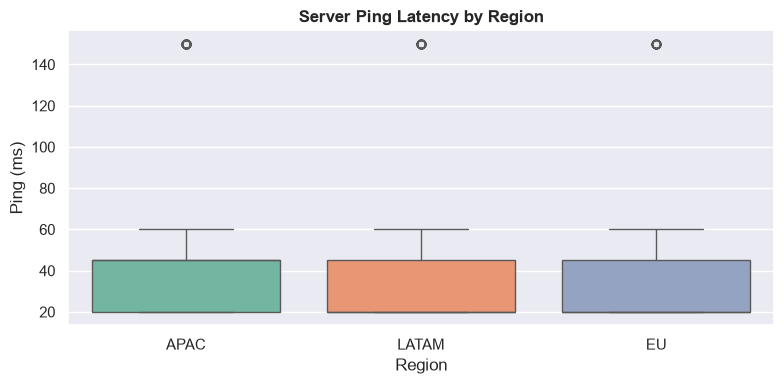

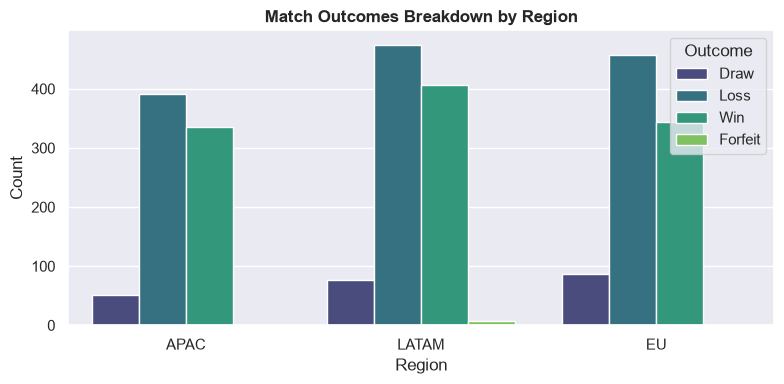

Tier 2 Visualizations successfully generated and saved!


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
conn = sqlite3.connect("gaming_data.db")

query = """
SELECT p.region, s.ping_ms, m.outcome
FROM players p
JOIN matches m ON p.player_id = m.player_id
JOIN sessions s ON p.player_id = s.player_id;
"""
df_viz = pd.read_sql_query(query, conn)
conn.close()

# Plot 1: Ping Latency Distribution by Region
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_viz, x="region", y="ping_ms", palette="Set2")
plt.title("Server Ping Latency by Region", fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Ping (ms)")
plt.tight_layout()
plt.savefig("ping_distribution.png")
plt.show()

# Plot 2: Match Outcomes by Region
plt.figure(figsize=(8, 4))
sns.countplot(data=df_viz, x="region", hue="outcome", palette="viridis")
plt.title("Match Outcomes Breakdown by Region", fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Count")
plt.legend(title="Outcome")
plt.tight_layout()
plt.savefig("match_outcomes.png")
plt.show()

print("Tier 2 Visualizations successfully generated and saved!")

In [ ]:
import sqlite3
import pandas as pd
from scipy import stats

# Connect to database
conn = sqlite3.connect("gaming_data.db")

# Query ping latency grouped by region
query = """
SELECT p.region, s.ping_ms
FROM players p
JOIN sessions s ON p.player_id = s.player_id;
"""
df_stats = pd.read_sql_query(query, conn)
conn.close()

# Group ping values by region
regions = [group["ping_ms"].values for _, group in df_stats.groupby("region")]

# Perform One-Way ANOVA Test
f_stat, p_value = stats.f_oneway(*regions)

print("--- Tier 3 Statistical Analysis ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: Statistically significant difference in ping latency across regions (p < 0.05).")
else:
    print("Result: No statistically significant difference in ping latency across regions.")